In [ ]:
# 1. LIBRERIE E CONFIGURAZIONE DELL'AMBIENTE SPARK

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    col,
    count,
    date_format,
    length,
    lit,
    pandas_udf,
    regexp_replace,
    to_date,
    to_timestamp,
    udf,
    when,
)
from pyspark.sql.types import DoubleType, StringType
import seaborn as sns
from textblob import TextBlob

# Installazione librerie esterne
!pip install pyspark langdetect pyarrow -q

# Configurazione sessione Spark ottimizzata per il singolo nodo di Google Colab
spark = (
    SparkSession.builder.appName("MarketPulse_Bitcoin_Sentiment")
    .config("spark.sql.shuffle.partitions", "4")  # Riduce lo shuffle overhead
    .config("spark.execution.arrow.pyspark.enabled", "true")  # Attiva Apache Arrow
    .getOrCreate()
)

print("Spark Session creata ed ottimizzata con successo:")
print(spark)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Spark Session creata ed ottimizzata con successo:


In [ ]:
# 2. DOWNLOAD E CARICAMENTO DEI DATASET

# Scarico i dataset
!wget -O tweets_bitcoin.csv "https://proai-datasets.s3.eu-west-3.amazonaws.com/bitcoin_tweets.csv" -q
!wget -O storico_prezzi_bitcoin.csv "https://raw.githubusercontent.com/Profession-AI/progetti-big-data/main/Analisi%20del%20consenso%20sul%20Bitcoin/BTC-USD.csv" -q

# Lettura ottimizzata dei file CSV
df_tweets = spark.read.csv("tweets_bitcoin.csv", header=True, inferSchema=False)
df_prezzi = spark.read.csv(
    "storico_prezzi_bitcoin.csv", header=True, inferSchema=True
)

print("Struttura dei dataset caricati:")
df_tweets.printSchema()
df_prezzi.printSchema()

Struttura dei dataset caricati:
root
 |-- id: string (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- replies: string (nullable = true)
 |-- likes: string (nullable = true)
 |-- retweets: string (nullable = true)
 |-- text: string (nullable = true)

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)



In [ ]:
# 3. VERIFICA PRELIMINARE DEI DATI GREZZI

print("I primi 5 tweet caricati:")
df_tweets.select("timestamp", "likes", "replies", "text").show(5, truncate=False)

print("\nI primi 5 record di prezzo del Bitcoin:")
df_prezzi.show(5)

I primi 5 tweet caricati:
+----------------------+-----+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|timestamp             |likes|replies|text                                                                                                                                                                                                                                  |
+----------------------+-----+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|2019-05-27 11:49:14+00|0.0  |0.0    |È appena uscito un nuovo video! LES CRYPTOMONNAIES QUI PULVÉRISENT BITCOIN EN 2019 https://t.co/yCsQMvRnyS                    

In [ ]:
# 4. PULIZIA TESTO, ESTRAZIONE DATA E FILTRO LINGUA INGLESE

from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

# 1. Filtro righe valide e timestamp coerenti
df_tweets_validi = df_tweets.dropna(subset=["timestamp", "text"])
df_tweets_prefiltered = df_tweets_validi.filter(
    col("timestamp").rlike("^\\d{4}-\\d{2}-\\d{2}.*$")
)

# 2. Conversione data e metriche numeriche
df_con_data = df_tweets_prefiltered.withColumn(
    "data_pulita",
    to_date(to_timestamp(col("timestamp"), "yyyy-MM-dd HH:mm:ssX")),
).dropna(subset=["data_pulita"])

df_convertito = df_con_data.withColumn(
    "likes_num", col("likes").cast(DoubleType())
).withColumn("replies_num", col("replies").cast(DoubleType()))

# 3. Pulizia regex avanzata del testo e filtro lunghezza
df_filtrato_base = (
    df_convertito.withColumn(
        "testo_pulito", regexp_replace(col("text"), "http\\S+|&amp;|[^\\w\\s]", "")
    )
    .withColumn(
        "testo_pulito", regexp_replace(col("testo_pulito"), "\\s+", " ")
    )
    .withColumn(
        "testo_pulito",
        regexp_replace(col("testo_pulito"), "^\\s+|\\s+$", ""),
    )
    .filter(length(col("testo_pulito")) > 5)
)


# 4. PANDAS UDF PER RILEVAMENTO LINGUA
@pandas_udf(StringType())
def detect_lang_pandas_udf(texts: pd.Series) -> pd.Series:
    def check_lang(text):
        try:
            if not text or len(str(text).strip()) < 5:
                return None
            return detect(str(text))
        except LangDetectException:
            return None

    return texts.apply(check_lang)


# 5. Applico il filtro lingua e SALVO IN RAM (cache) per azzerare i ricalcoli futuri
df_pulito = df_filtrato_base.withColumn(
    "lingua", detect_lang_pandas_udf(col("testo_pulito"))
)
df_pulito = df_pulito.filter(col("lingua") == "en").cache()

print("Verifico i dati dopo la pulizia e il filtro lingua inglese:")
df_pulito.select("data_pulita", "lingua", "testo_pulito").show(5, truncate=False)

Verifico i dati dopo la pulizia e il filtro lingua inglese:
+-----------+------+----------------------------------------------------------------------------------------------------------------------------------------------------+
|data_pulita|lingua|testo_pulito                                                                                                                                        |
+-----------+------+----------------------------------------------------------------------------------------------------------------------------------------------------+
|2019-05-27 |en    |Cardano Digitize Currencies EOS 6500 ROI ATT Bitcoin Bill Pay Cardano ADA FolloForFolloBack follo4folloback followforfollow bitcointe cryptocurrency|
|2019-05-27 |en    |Another Test tweet that wasnt caught in the stream bitcoin                                                                                          |
|2019-05-27 |en    |Current Crypto Prices                                                 

In [ ]:

# 5. CALCOLO DEL SENTIMENT CON TEXTBLOB (PANDAS UDF OPTIMIZED)

df_for_sentiment = df_pulito.select(
    "data_pulita", "testo_pulito", "likes_num", "replies_num"
)


# Pandas UDF per TextBlob
@pandas_udf(StringType())
def sentiment_pandas_udf(texts: pd.Series) -> pd.Series:
    def get_sentiment(text):
        if not text:
            return "neutro"
        pol = TextBlob(str(text)).sentiment.polarity
        return "positivo" if pol > 0 else ("negativo" if pol < 0 else "neutro")

    return texts.apply(get_sentiment)


# Applicazione diretta vettorizzata
df_con_sentiment = df_for_sentiment.withColumn(
    "sentiment", sentiment_pandas_udf(col("testo_pulito"))
).cache()

# Aggregazione giornaliera per il riassunto
df_trend_giornaliero = (
    df_con_sentiment.groupBy("data_pulita", "sentiment")
    .count()
    .orderBy("data_pulita")
)

print("Calcolo del sentiment completato con successo. Riassunto giornaliero:")
df_trend_giornaliero.show(15)

Calcolo del sentiment completato con successo. Riassunto giornaliero:
+-----------+---------+-----+
|data_pulita|sentiment|count|
+-----------+---------+-----+
| 2009-01-11|   neutro|    1|
| 2012-08-02| positivo|    1|
| 2013-08-16| positivo|    1|
| 2013-12-09|   neutro|    1|
| 2013-12-19|   neutro|    1|
| 2013-12-20|   neutro|    1|
| 2014-02-20| positivo|    1|
| 2014-07-12|   neutro|    1|
| 2014-12-12|   neutro|    1|
| 2015-02-14|   neutro|    1|
| 2015-09-02| positivo|    1|
| 2015-11-19|   neutro|    1|
| 2016-02-19|   neutro|    1|
| 2016-03-28|   neutro|    3|
| 2016-05-03|   neutro|    2|
+-----------+---------+-----+
only showing top 15 rows


In [ ]:
# 6. ANALISI DELL'ENGAGEMENT MEDIO PER SENTIMENT

df_engagement = df_con_sentiment.groupBy("sentiment").agg(
    avg("likes_num").alias("media_likes"),
    avg("replies_num").alias("media_risposte"),
)

print("Ecco il report medio dell'engagement in base al sentiment:")
df_engagement.show()

Ecco il report medio dell'engagement in base al sentiment:
+---------+-----------------+------------------+
|sentiment|      media_likes|    media_risposte|
+---------+-----------------+------------------+
|   neutro|7.850565955594253|0.8259686547670875|
| positivo|8.276405499049961|1.1101300249618122|
| negativo|8.618325642715886|0.9073170731707317|
+---------+-----------------+------------------+



In [ ]:
# 7. PIVOT GIORNALIERO E JOIN CON LO STORICO PREZZI BITCOIN

# 1. Pivot del sentiment giornaliero
df_sentiment_pivot = (
    df_con_sentiment.groupBy("data_pulita")
    .pivot("sentiment")
    .count()
    .na.fill(0)
)

df_sentiment_finale = (
    df_sentiment_pivot.withColumnRenamed("positivo", "tweet_positivi")
    .withColumnRenamed("negativo", "tweet_negativi")
    .withColumnRenamed("neutro", "tweet_neutri")
)

# 2. Estrazione data dallo storico prezzi
df_prezzi_pulito = df_prezzi.withColumn("data_pulita", to_date(col("Date")))

# 3. Inner Join sui dati aggregati
df_analisi_correlazione = df_sentiment_finale.join(
    df_prezzi_pulito, on="data_pulita", how="inner"
)

# 4. Selezione colonne e salvataggio in cache
df_output_correlazione = df_analisi_correlazione.select(
    "data_pulita",
    "tweet_positivi",
    "tweet_negativi",
    "tweet_neutri",
    "Close",
).orderBy("data_pulita")
df_output_correlazione = df_output_correlazione.cache()

print(
    "Ecco il dataset unito: sentiment giornaliero e prezzo di chiusura del Bitcoin (Close):"
)
df_output_correlazione.show(15)

Ecco il dataset unito: sentiment giornaliero e prezzo di chiusura del Bitcoin (Close):
+-----------+--------------+--------------+------------+------------------+
|data_pulita|tweet_positivi|tweet_negativi|tweet_neutri|             Close|
+-----------+--------------+--------------+------------+------------------+
| 2014-12-12|             0|             0|           1|    352.5419921875|
| 2015-02-14|             0|             0|           1| 257.3210144042969|
| 2015-09-02|             1|             0|           0|229.28399658203125|
| 2015-11-19|             0|             0|           1|326.14898681640625|
| 2016-02-19|             0|             0|           1| 420.7850036621094|
| 2016-03-28|             0|             0|           3| 424.2309875488281|
| 2016-05-03|             0|             0|           2| 450.3039855957031|
| 2016-05-15|             1|             0|           0| 457.5679931640625|
| 2016-05-19|             0|             0|           2| 438.7149963378906|
|

In [ ]:
# 8. CALCOLO DELL'INDICE DI CORRELAZIONE DI PEARSON

import pyspark.sql.functions as F

print("Inizio esecuzione cella di correlazione.", flush=True)

# Verifica dello schema e conteggio
num_righe = df_output_correlazione.count()
print(f"\nVerifica del DataFrame - Numero di righe: {num_righe}", flush=True)

print("\nSchema delle colonne:")
df_output_correlazione.printSchema()

print("\nPrime 5 righe:")
df_output_correlazione.select("tweet_positivi", "tweet_negativi", "Close").show(
    5
)

print("\nStatistiche descrittive:")
df_output_correlazione.describe(
    "tweet_positivi", "tweet_negativi", "Close"
).show()

# 1. Calcolo correlazione Tweet Positivi vs Close
try:
  print("\nTento il calcolo della correlazione per Tweet Positivi...", flush=True)
  correlazione_positivi = df_output_correlazione.stat.corr(
      "tweet_positivi", "Close"
  )
  print(
      f"Valore raw per correlazione_positivi: {correlazione_positivi} (Tipo:"
      f" {type(correlazione_positivi)})",
      flush=True,
  )
except Exception as e:
  correlazione_positivi = f"ERRORE: {e}"
  print(f"Errore durante il calcolo correlazione positivi: {e}", flush=True)

# 2. Calcolo correlazione Tweet Negativi vs Close
try:
  print("\nTento il calcolo della correlazione per Tweet Negativi...", flush=True)
  correlazione_negativi = df_output_correlazione.stat.corr(
      "tweet_negativi", "Close"
  )
  print(
      f"Valore raw per correlazione_negativi: {correlazione_negativi} (Tipo:"
      f" {type(correlazione_negativi)})",
      flush=True,
  )
except Exception as e:
  correlazione_negativi = f"ERRORE: {e}"
  print(f"Errore durante il calcolo correlazione negativi: {e}", flush=True)

# 3. Risultati finali
print("\nRISULTATI STRATEGICI DELLA CORRELAZIONE:", flush=True)
print(
    f"Indice di correlazione tra Tweet Positivi e Prezzo: {correlazione_positivi}"
)
print(
    f"Indice di correlazione tra Tweet Negativi e Prezzo: {correlazione_negativi}"
)

print("\nCella di correlazione terminata.", flush=True)

Inizio esecuzione cella di correlazione.

Verifica del DataFrame - Numero di righe: 492

Schema delle colonne:
root
 |-- data_pulita: date (nullable = true)
 |-- tweet_positivi: long (nullable = true)
 |-- tweet_negativi: long (nullable = true)
 |-- tweet_neutri: long (nullable = true)
 |-- Close: double (nullable = true)


Prime 5 righe:
+--------------+--------------+------------------+
|tweet_positivi|tweet_negativi|             Close|
+--------------+--------------+------------------+
|             0|             0|    352.5419921875|
|             0|             0| 257.3210144042969|
|             1|             0|229.28399658203125|
|             0|             0|326.14898681640625|
|             0|             0| 420.7850036621094|
+--------------+--------------+------------------+
only showing top 5 rows

Statistiche descrittive:
+-------+------------------+------------------+------------------+
|summary|    tweet_positivi|    tweet_negativi|             Close|
+-------+-------

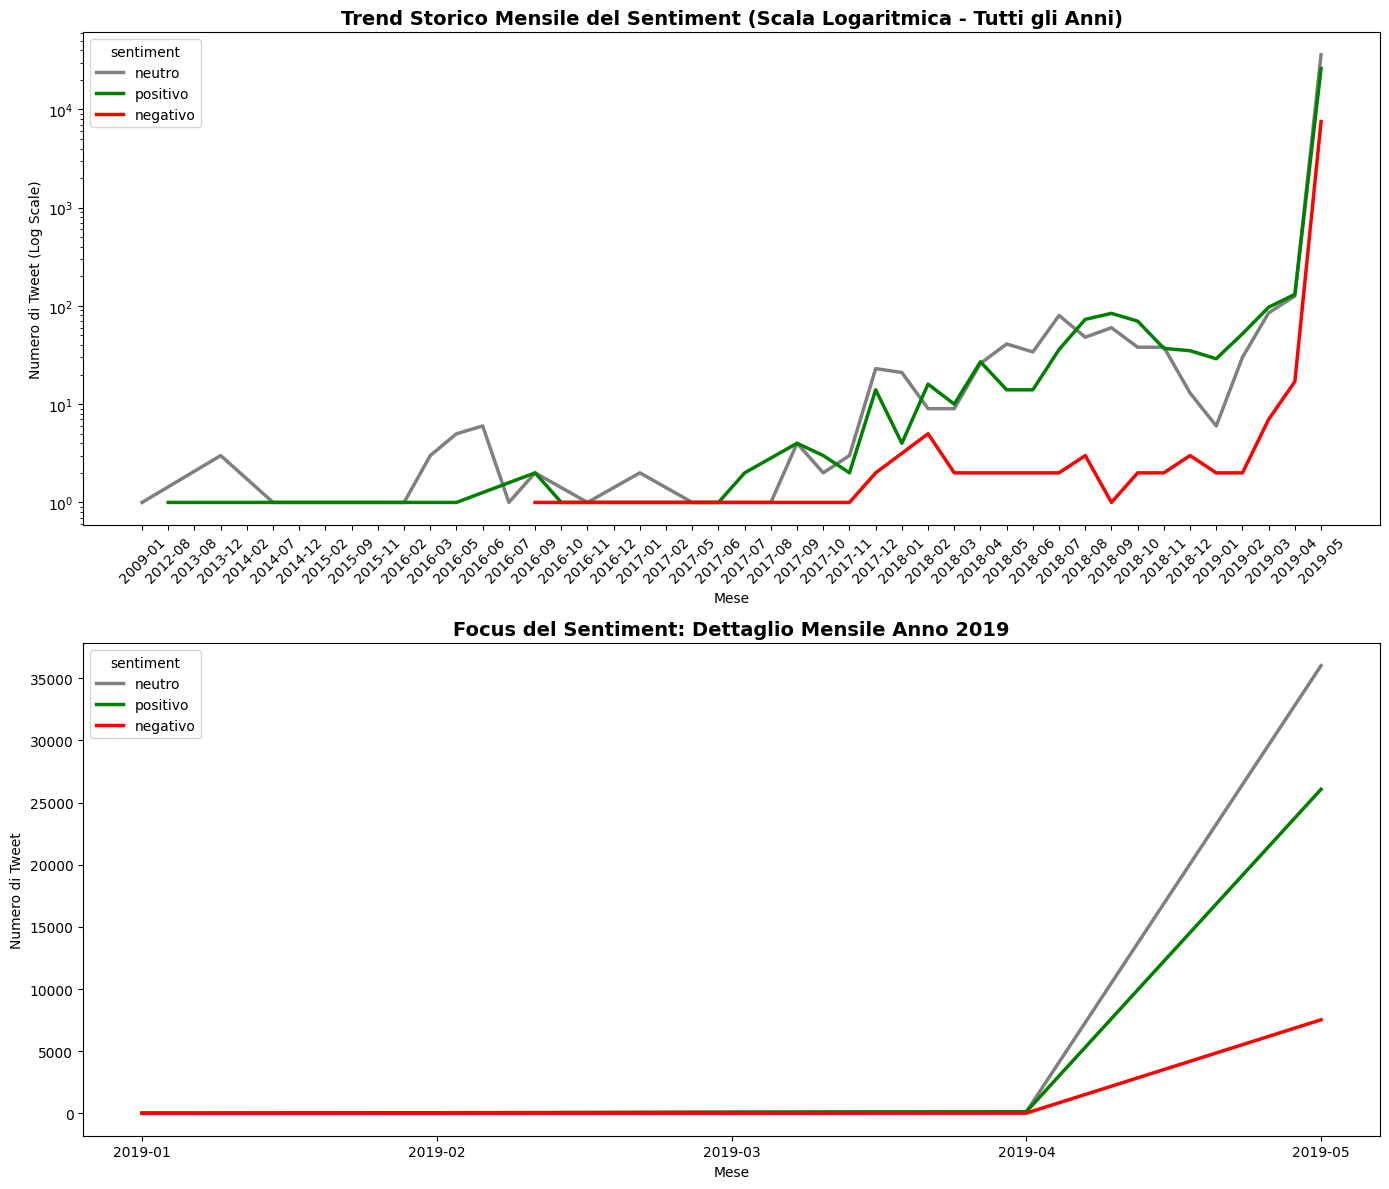

In [ ]:
# 9. GENERAZIONE DEI GRAFICI TEMPORALI (STORICO LOGARITMICO + FOCUS 2019)

# Aggregazione mensile
df_trend_mensile = (
    df_con_sentiment.groupBy(
        date_format(col("data_pulita"), "yyyy-MM").alias("mese"), "sentiment"
    )
    .count()
    .orderBy("mese")
)

# Conversion in Pandas per il plotting
pdf_trend_mensile = df_trend_mensile.toPandas().sort_values("mese")
pdf_trend_2019 = pdf_trend_mensile[
    pdf_trend_mensile["mese"].str.startswith("2019")
]

# Configurazione Subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# GRAFICO 1: Trend Storico Completo (Scala Logaritmica)
sns.lineplot(
    data=pdf_trend_mensile,
    x="mese",
    y="count",
    hue="sentiment",
    palette={"positivo": "green", "negativo": "red", "neutro": "gray"},
    linewidth=2.5,
    ax=ax1,
)
ax1.set_yscale("log")
ax1.set_title(
    "Trend Storico Mensile del Sentiment (Scala Logaritmica - Tutti gli Anni)",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Mese")
ax1.set_ylabel("Numero di Tweet (Log Scale)")
ax1.tick_params(axis="x", rotation=45)

# GRAFICO 2: Focus sull'Anno 2019 (Scala Lineare)
sns.lineplot(
    data=pdf_trend_2019,
    x="mese",
    y="count",
    hue="sentiment",
    palette={"positivo": "green", "negativo": "red", "neutro": "gray"},
    linewidth=2.5,
    ax=ax2,
)
ax2.set_title(
    "Focus del Sentiment: Dettaglio Mensile Anno 2019",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Mese")
ax2.set_ylabel("Numero di Tweet")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()